## 0. Computervision libraries

1. torchvision
2. torchvision.datasets - get datasets
3. torchvision.models - pretrained computervision models
4. torchvision.transforms - function for transforming image to numbers/ encoding
5. torch utils.data.DataLoader - creates python iterables

In [138]:
import torch
from torch import nn

# for vison models
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

#matplotlib for vizz
import matplotlib.pyplot as plt

#Check versions
print(torch.__version__)
print(torchvision.__version__)

2.6.0+cu124
0.21.0+cu124


## 1. Getting a dataset - FashionMNIST

In [139]:
#Setup training datasets
train_data = datasets.FashionMNIST(
   root = 'data', #where to download
   train = True,
   download = True,
   transform = ToTensor(), #torchvision.transform.ToTensor
   target_transform = None #how do we want to transform the labels or targets
)

test_data = datasets.FashionMNIST(
   root = 'data', #where to download
   train = False,
   download = True,
   transform = ToTensor(), #torchvision.transform.ToTensor
   target_transform = None #how do we want to transform the labels or targets
)

In [140]:
len(train_data), len(test_data)

(60000, 10000)

In [141]:
#See the first trainng sample
image, label = train_data[0]
image.shape, label

(torch.Size([1, 28, 28]), 9)

In [142]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [143]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [144]:
#Check the shape of the data
print(f'image shape: {image.shape} -> [color_channels, height, width]')
print(f'label shape: {class_names[label]}')

image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]
label shape: Ankle boot


### 1.2 Visualising our data

image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]
label shape: Ankle boot


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

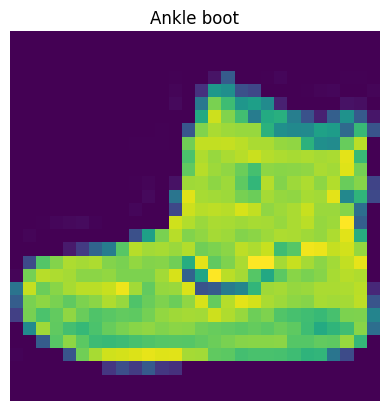

In [145]:
#visualize visualizeeee

image, label = train_data[0]
print(f'image shape: {image.shape} -> [color_channels, height, width]')
print(f'label shape: {class_names[label]}')

plt.imshow(image.squeeze())
plt.title(class_names[label])
plt.axis(False)


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

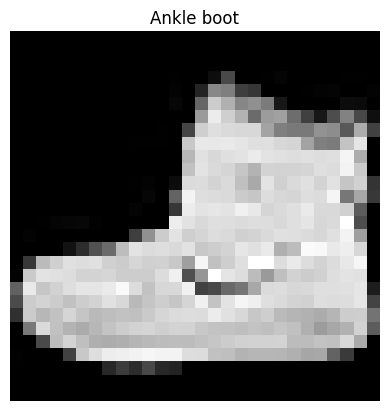

In [146]:
plt.imshow(image.squeeze(), cmap = 'gray')
plt.title(class_names[label])
plt.axis(False)

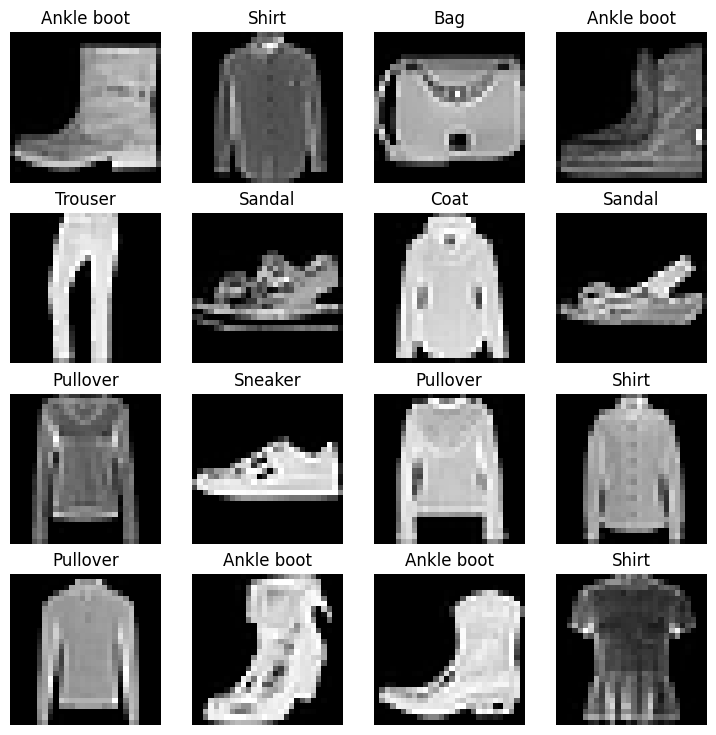

In [147]:
torch.manual_seed(42)
fig = plt.figure(figsize = (9,9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data), size = [1]).item()
  image, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.squeeze(), cmap = 'gray')
  plt.title(class_names[label])
  plt.axis(False)

Are these images of clothing linear or non linear?

In [148]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 2. Prepare DataLoader

Right now the data is in PyTorch datasets

DataLoader turns the dataset into a python iterable(Logits or Tensors)

Turn our data into batches or mini batches

Why would we do this?

1. Its is more computationally efficient (usually 32)
2. It gives our NN more chances to update the gradients per epoch

In [149]:
from torch.utils.data import DataLoader

#setup a size hyperparameter
BATCH_SIZE = 32

#Turn data into batches or iterables
train_dataloader =  DataLoader(train_data, batch_size = BATCH_SIZE, shuffle = True)
test_dataloader = DataLoader(test_data, batch_size = BATCH_SIZE, shuffle = False)#for evaluation the test data is better to be in the same order

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7a0754647c10>,
 <torch.utils.data.dataloader.DataLoader at 0x7a0754667c90>)

In [150]:
#Check out what is created
print(f'Dataloader: {train_dataloader}\nLength: {len(train_dataloader)}\nType: {type(train_dataloader)}')
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloader: <torch.utils.data.dataloader.DataLoader object at 0x7a0754647c10>
Length: 1875
Type: <class 'torch.utils.data.dataloader.DataLoader'>
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [151]:
#check out train datalaoder
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

image size: torch.Size([1, 28, 28])
Label: Bag and size: torch.Size([])


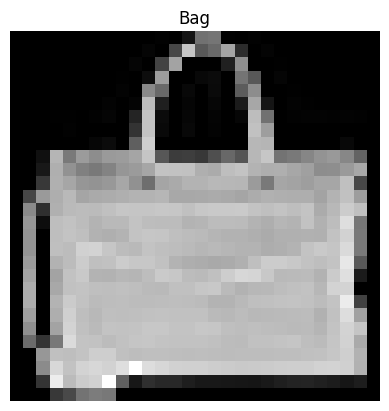

In [152]:
#visualising a single image from a batch
# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
image, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(image.squeeze(), cmap = 'gray')
plt.title(class_names[label])
plt.axis(False)
print(f"image size: {image.shape}")
print(f'Label: {class_names[label]} and size: {label.shape}')

## 3. Model 0: Building a baseline model

Usually we build a base model and start developing it further with experiments. THerefore stariting simply and improving the complexity as we improve.

In [153]:
 #creating a flatten layer
 flatten_model = nn.Flatten()

 #get a single sample
 x= train_features_batch[0]
 x.shape

#Flatten the sample
 output = flatten_model(x)

#print out
print(f'shape before flattening: {x.shape}')
print(f'shape after flattening: {output.shape}')

shape before flattening: torch.Size([1, 28, 28])
shape after flattening: torch.Size([1, 784])


In [154]:
from torch import nn

class FashionMNISTModelV0(nn.Module):
  def __init__(self, input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_shape, out_features = hidden_units),
        nn.Linear(in_features = hidden_units, out_features = output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)

In [155]:
torch.manual_seed(42)

#setup model with inputs
model_0 = FashionMNISTModelV0(input_shape = 28*28,
                              hidden_units = 10,
                              output_shape = len(class_names)
                              )

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [156]:
dummy_x = torch.rand(size = (1, 1, 28, 28))
print(dummy_x.shape)
model_0(dummy_x)

torch.Size([1, 1, 28, 28])


tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

### 3.1 Setup Loss, optimizer and evaluation metrics

* Loss Funtion: Since we are working with multiclass -> 'nn.CrissEntropyLoss'
* Optimizer: 'torch.optim.SGD'
* Metrics: 'torchmetrics.Accuracy'

In [157]:
import requests
from pathlib import Path

#Download helperfunctions from learnpytorch
if Path('helperfunctions.py').is_file():
  print('helperfunctions.py already exists')
else:
  print('Downloading helperfunctions.py')
  request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
  with open('helper_functions.py', 'wb') as f:
    f.write(request.content)


In [158]:
#import the accuracy metrics
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.1)

###3.2 Creating a function to time our experiments

Machine learning is very experimental

to track
1. model's performance (loss and accuracy values)
2. How fast does the model run

In [159]:
from timeit import default_timer as timer

def print_train_time(start: float,
                     end: float,
                     device = None):
  """ print difference between start and end time """

  total_time = end - start
  print(f'Train time on {device}: {total_time:.3f} seconds')
  return total_time

In [160]:
start_time = timer()
#...other code
end_time = timer()
print_train_time(start = start_time, end = end_time, device = 'cpu')

Train time on cpu: 0.000 seconds


3.7708000036218436e-05

### 3.3 Creating a training loop and training a model of batches of data

1. Loop through epochs
2. loop through training batches
3. loop through testing batches
4. print out whats happening
5. timing for analysis (CPU vs GPU)

In [161]:
# import tqdm for progress bar
from tqdm.auto import tqdm

#set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

#set number of epochs
epochs = 3

#create training and test loop
for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n-------')
  ### Training
  train_loss, train_acc = 0, 0
  #add a loop to loop through training batches
  for batch, (X, y) in enumerate(train_dataloader):
    model_0.train()
    # 1. Forward pass
    y_pred = model_0(X)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y)
    train_loss += loss # accumulate train loss

    # 3. optimizer zero grad
    optimizer.zero_grad()

    # 4. loss backward
    loss.backward()

    # 5. optimizer step
    optimizer.step()

    # print out how many batches
    if batch % 400 == 0:
      print(f'Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples')

  #adjust the training loss to get the average loss
  #Divide the total train loss by the length of the train dataloader
  train_loss /= len(train_dataloader)

  ### Testing
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      #1. forward pass
      test_pred = model_0(X_test)

      #2. calculate the loss (accumulatively)
      test_loss += loss_fn(test_pred, y_test)

      #3. calculate the accuracy
      test_acc += accuracy_fn(y_true = y_test, y_pred = test_pred.argmax(dim = 1))

    #calculate the test loss average per batch
    test_loss /= len(test_dataloader)

    #calculate the test accuracy
    test_acc /= len(test_dataloader)

  #print out the train and test
  print(f'Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}')

#Calculate the training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start = train_time_start_on_cpu,
                                            end = train_time_end_on_cpu,
                                            device = str(next(model_0.parameters()).device))




  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.5904 | Test loss: 0.5095 | Test acc: 82.0387
Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.4763 | Test loss: 0.4799 | Test acc: 83.1969
Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.4550 | Test loss: 0.4766 | Test acc: 83.4265
Train time on cpu: 25.413 seconds


###4.make predictions  and get model_0

In [162]:
torch.manual_seed(42)

def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  """Return a dictionary containing the results of the model predicting the data_loader"""
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      #Make predictions
      y_pred = model(X)

      #Accumulate the loss and accuracy values per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true = y, y_pred = y_pred.argmax(dim = 1))

    #Scale the loss and acc
    loss /= len(data_loader)
    acc /= len(data_loader)

    return {'model_name': model.__class__.__name__, #only works when model was created with classes
            'model_loss': loss.item(),
            'model_acc': acc}

#Calculate the model 0 results on dataset
model_0_results = eval_model(model = model_0,
                             data_loader = test_dataloader,
                             loss_fn = loss_fn,
                             accuracy_fn = accuracy_fn)

model_0_results


  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

## 5.  Setup device agnostic code (use gpu if it exists)

In [163]:
!nvidia-smi

Sun Jul 13 09:13:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             33W /   70W |     166MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [164]:
torch.cuda.is_available()

True

##6. Model 1: Building a better model with non-Linearity

Non Linearity was understood in nodebook_02 Classification



In [165]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [166]:
#Create a Non Linear and linear layers
class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_shape,
                  out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units,
                  out_features = output_shape)
    )

  def forward(self, x: torch.Tensor):
    return self.layer_stack(x)

In [167]:
#create an instance of model 1
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape = 28*28,
                              hidden_units = 10,
                              output_shape = len(class_names)).to(device)

next(model_1.parameters()).device

device(type='cuda', index=0)

## 6.1 Create a loss optimizer and evaluation metrics


In [168]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss() #Measure how wrong the model is
optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr = 0.01) # tries to update the parameters to reduce loss

In [169]:
from timeit import default_timer as timer

def print_train_time(start: float,
                     end: float,
                     device = 'cuda'):
  """ print difference between start and end time """

  total_time = end - start
  print(f'Train time on {device}: {total_time:.3f} seconds')
  return total_time

### 6.2 functionising training and evaluation

Lets create a function for:

* training loop - train_step()
* testing loop - test_step()

In [170]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [171]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):

  """Performs a training with model trying to learn of Data_loader"""

  ### Training
  train_loss, train_acc = 0, 0

  #Put model into training mode
  model.train()

  #add a loop to loop through training batches
  for batch, (X, y) in enumerate(data_loader):
    #Put data into target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass(outputs the raw logits to model)
    y_pred = model(X)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y)
    train_loss += loss# accumulate train loss
    train_acc += accuracy_fn(y_true = y,
                             y_pred = y_pred.argmax(dim = 1))

    # 3. optimizer zero grad
    optimizer.zero_grad()

    # 4. loss backward
    loss.backward()

    # 5. optimizer step
    optimizer.step()

    #Divide total trian loss and acc by length of train dataloader
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%\n")

In [172]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
  """ Performs a testing with model trying to learn of Data_loader"""

  ### Testing
  test_loss, test_acc = 0, 0
  #put the model in eval mode
  model.eval()

  with torch.inference_mode():
    for X_test, y_test in data_loader:
      #Put data into target device
      X_test, y_test = X_test.to(device), y_test.to(device)

      #1. Forward pass
      test_pred = model(X_test)

      #2. Calculate the loss/acc
      test_loss += loss_fn(test_pred, y_test)
      test_acc += accuracy_fn(y_true = y_test,
                              y_pred = test_pred.argmax(dim=1))

    #Adjust the metrics and print out
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
  print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%\n")


In [173]:
torch.manual_seed(42)

#Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

#set epochs
epochs = 3

#Create an optimisation and evaluation loop using train_step() and test_step()
for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n-------')
  train_step(model = model_1,
             data_loader = train_dataloader,
             loss_fn = loss_fn,
             optimizer = optimizer,
             accuracy_fn = accuracy_fn,
             device = device)
  test_step(model = model_1,
            data_loader = test_dataloader,
            loss_fn = loss_fn,
            accuracy_fn = accuracy_fn,
            device = device)

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start = train_time_start_on_gpu,
                                            end = train_time_end_on_gpu,
                                            device = str(next(model_1.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.00026 | Train acc: 0.05%

Test loss: 0.69526 | Test acc: 75.64%

Epoch: 1
-------
Train loss: 0.00032 | Train acc: 0.04%

Test loss: 0.58169 | Test acc: 79.37%

Epoch: 2
-------
Train loss: 0.00021 | Train acc: 0.05%

Test loss: 0.54453 | Test acc: 80.86%

Train time on cuda:0: 30.408 seconds


In [174]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

In [175]:
total_train_time_model_0

25.41326266599981

In [176]:
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  """Return a dictionary containing the results of the model predicting the data_loader"""
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      # Make to device agnostic
      X, y = X.to(device), y.to(device)
      #Make predictions
      y_pred = model(X)

      #Accumulate the loss and accuracy values per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true = y, y_pred = y_pred.argmax(dim = 1))

    #Scale the loss and acc
    loss /= len(data_loader)
    acc /= len(data_loader)

    return {'model_name': model.__class__.__name__, #only works when model was created with classes
            'model_loss': loss.item(),
            'model_acc': acc}

In [177]:
#Get model_1 results dictionary
model_1_results = eval_model(model = model_1,
                             data_loader = test_dataloader,
                             loss_fn = loss_fn,
                             accuracy_fn = accuracy_fn)

model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.5445324182510376,
 'model_acc': 80.86062300319489}

In [178]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

## Model 2: Building a CNN

CNNs are also known as Convnets

They are also known to find patterns in visual data

To get a more explained view of cnn https://poloclub.github.io/cnn-explainer/

In [179]:
#Create a convolutional neural network
class FashionMNISTModelV2(nn.Module):
  """
  Model architecture replicated from TinyVGG
  Model from CNN explainer website linked above
  """
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),#Values we set ourselves are called hyperparameters
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride = 2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  padding = 1,
                  stride = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
          out_channels = hidden_units,
          kernel_size = 3,
          padding = 1,
          stride = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride = 2)
    )
    #Final output layer is called classifier layer
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units*7*7,
                  out_features = output_shape)
    )
  def forward(self, x):
    x = self.conv_block_1(x)
    # print(f"output of ConvBlock1: {x.shape}")
    x = self.conv_block_2(x)
    # print(f"output of ConvBlock1: {x.shape}")
    x = self.classifier(x)
    # print(f"output of classifier: {x.shape}")
    return x


In [180]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape = 1,
                              hidden_units = 10,
                              output_shape = len(class_names)).to(device)

next(model_2.parameters()).device

device(type='cuda', index=0)

In [181]:
model_2.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 0.2548,  0.2767, -0.0781],
                        [ 0.3062, -0.0730,  0.0673],
                        [-0.1623,  0.1958,  0.2938]]],
              
              
                      [[[-0.2445,  0.2897,  0.0624],
                        [ 0.2463,  0.0451,  0.1607],
                        [-0.0471,  0.2570,  0.0493]]],
              
              
                      [[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
      

## 7.1 Stepping through 'nn.Conv2d()'

In [182]:
torch.manual_seed(42)

#create a batch of images
images = torch.randn(size=(32,3,64,64))
test_image = images[0]

print(f"Shape of test image: {test_image.shape}")
print(f"Shape of batch of images: {images.shape}")
print(f"Test images: \n{images}")

Shape of test image: torch.Size([3, 64, 64])
Shape of batch of images: torch.Size([32, 3, 64, 64])
Test images: 
tensor([[[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
          [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
          [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
          ...,
          [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
          [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
          [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

         [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
          [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
          [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
          ...,
          [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
          [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
          [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  

In [183]:
test_image.shape

torch.Size([3, 64, 64])

In [184]:
# create a single conv2d layer
conv_layer = nn.Conv2d(in_channels = 3,
                       out_channels = 10,
                       kernel_size = 3,
                       stride = 1,
                       padding = 1)

#Pass the data through convolutional layer
conv_output = conv_layer(test_image.unsqueeze(0))
conv_output.shape

torch.Size([1, 10, 64, 64])

### 7.2 Stepping through nn.MaxPool2d()

In [185]:
test_image.shape

torch.Size([3, 64, 64])

In [186]:
#Print out original image shape without unsqueezed
print(f"Shape of test image: {test_image.shape}")
print(f"Shape of unsqueezed dimension: {test_image.unsqueeze(0).shape}")

# Create a sample nn.MaxPool2d layer
max_pool_layer = nn.MaxPool2d(kernel_size = 2,
                              stride = 2)

# Pass data through Conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape of test image through conv: {test_image_through_conv.shape}")

#Pass the data through MaxPool layer
max_pool_and_conv_layer_output = max_pool_layer(test_image_through_conv)
max_pool_and_conv_layer_output.shape

Shape of test image: torch.Size([3, 64, 64])
Shape of unsqueezed dimension: torch.Size([1, 3, 64, 64])
Shape of test image through conv: torch.Size([1, 10, 64, 64])


torch.Size([1, 10, 32, 32])

In [187]:
torch.manual_seed(42)
#create a random tensor with a similar number of dimensions
random_tensor = torch.randn(size = (1,1,2,2))
print(f"Random Tensor: {random_tensor}")
print(f"Random Tensor shape: {random_tensor.shape}")

#create a maxpool layer
max_pool_layer=nn.MaxPool2d(kernel_size=2)

#Pass the random tesor through the maxpool layer
max_pool_tensor = max_pool_layer(random_tensor)

print(f"MaxPool Tensored: {max_pool_tensor}")
print(f"MaxPool Tensor shape: {max_pool_tensor.shape}")

Random Tensor: tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
Random Tensor shape: torch.Size([1, 1, 2, 2])
MaxPool Tensored: tensor([[[[0.3367]]]])
MaxPool Tensor shape: torch.Size([1, 1, 1, 1])


In [188]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape = 1,
                              hidden_units = 10,
                              output_shape = len(class_names)).to(device)


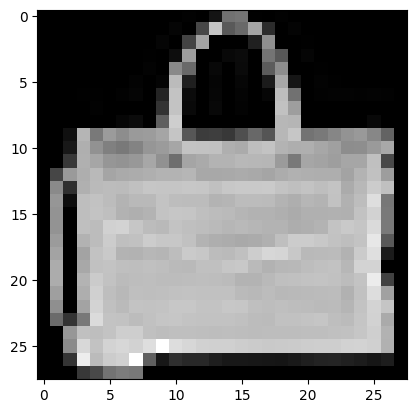

In [189]:
plt.imshow(image.squeeze(), cmap = 'gray')

In [190]:
rand_image_tensor = torch.randn(size = (1,28,28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [191]:
model_2(rand_image_tensor.unsqueeze(dim=0).to(device))

tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], device='cuda:0', grad_fn=<AddmmBackward0>)

### 7.3 Setup loss function and optimizer for model_2

In [192]:
# Setup loss function/eval metrics/optimizer
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_2.parameters(),
                            lr = 0.1)

### 7.4 Training and testing model_' using our train and test functions

In [193]:
torch.manual_seed(42)
torch.cuda.manual_seed

#measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

#Train and test model
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n-------')
  train_step(model = model_2,
             data_loader = train_dataloader,
             loss_fn = loss_fn,
             optimizer = optimizer,
             accuracy_fn = accuracy_fn,
             device = device)
  test_step(model = model_2,
            data_loader = test_dataloader,
            loss_fn = loss_fn,
            accuracy_fn = accuracy_fn,
            device = device)

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start = train_time_start_model_2,
                                            end = train_time_end_model_2,
                                            device = device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.00021 | Train acc: 0.05%

Test loss: 0.39068 | Test acc: 85.88%

Epoch: 1
-------
Train loss: 0.00023 | Train acc: 0.04%

Test loss: 0.35945 | Test acc: 86.39%

Epoch: 2
-------
Train loss: 0.00016 | Train acc: 0.05%

Test loss: 0.32855 | Test acc: 88.52%

Train time on cuda: 40.126 seconds


In [196]:
# get model_2 results
model_2_results = eval_model(model = model_2,
                             data_loader = test_dataloader,
                             loss_fn = loss_fn,
                             accuracy_fn = accuracy_fn)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3285456895828247,
 'model_acc': 88.51837060702876}

## 8. Comparing the results and training time

In [197]:
import pandas as pd
compare_results = pd.DataFrame(data = [model_0_results,
                                       model_1_results,
                                       model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.544532,80.860623
2,FashionMNISTModelV2,0.328546,88.518371


In [198]:
#Add training time to results comparison
compare_results['training_time'] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]
compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,83.426518,25.413263
1,FashionMNISTModelV1,0.544532,80.860623,30.407720
2,FashionMNISTModelV2,0.328546,88.518371,40.126083


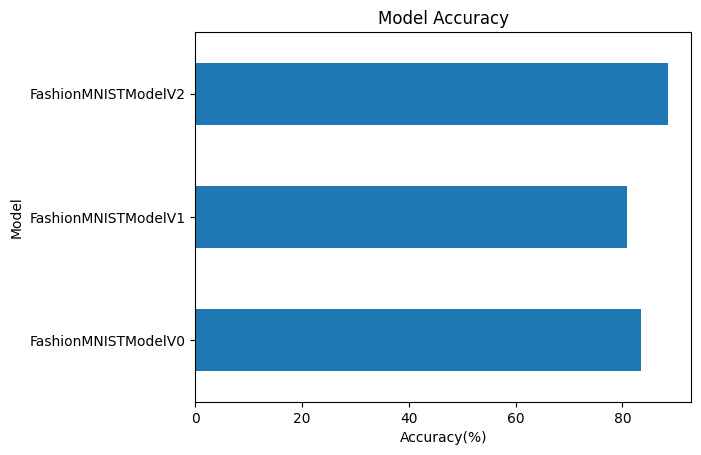

In [202]:
#Visualise our model results
compare_results.set_index('model_name')['model_acc'].plot(title = 'Model Accuracy',
                                                          kind = 'barh')
plt.xlabel('Accuracy(%)')
plt.ylabel('Model');

## 9. Make and evaluate random predictions with the best model

In [207]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      #Prepare the sa,ple (add a batch dimensions and pass to target device)
      sample = torch.unsqueeze(sample, dim = 0).to(device)

      # Forward pass (model outputs raw logits)
      pred_logit = model(sample)

      #Get the prediction probability
      pred_prob = torch.softmax(pred_logit.squeeze(), dim = 0)

      #Get pred probs off the GPU
      pred_probs.append(pred_prob.cpu())

      # #Get the prediction label
      # pred_label = torch.argmax(pred_prob)
  #stack pred_probs to turn list into a tensor
  return torch.stack(pred_probs)

In [208]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [236]:
import random
#random.seed(42)

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k = 9):
  test_samples.append(sample)
  test_labels.append(label)

#View the first sample shape
test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Prediction: Sandal')

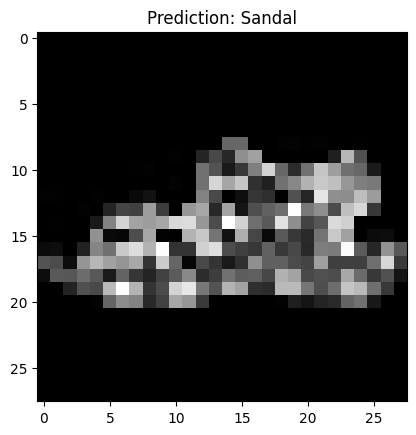

In [242]:
plt.imshow(test_samples[0].squeeze(), cmap = 'gray')
plt.title(f'Prediction: {class_names[test_labels[0]]}')

In [243]:
#Make predictions
pred_probs = make_predictions(model = model_2,
                              data = test_samples)
pred_probs

tensor([[6.3490e-07, 2.4995e-06, 1.1558e-06, 8.0292e-06, 8.5654e-06, 9.9953e-01,
         3.0268e-06, 2.1311e-04, 8.8918e-05, 1.4267e-04],
        [2.1996e-03, 5.5835e-06, 9.2688e-02, 6.7769e-04, 4.1621e-02, 7.8211e-06,
         8.6273e-01, 2.0690e-06, 6.5155e-05, 4.1608e-06],
        [7.3913e-04, 3.3769e-05, 1.1418e-02, 1.1980e-04, 5.1008e-02, 6.0309e-06,
         9.3583e-01, 1.7356e-06, 8.3370e-04, 1.3723e-05],
        [4.6854e-03, 2.8239e-04, 5.6377e-02, 2.0160e-03, 4.3189e-01, 1.5064e-05,
         5.0160e-01, 1.9101e-06, 3.1151e-03, 2.4873e-05],
        [1.3095e-03, 1.6509e-04, 4.4118e-06, 9.9792e-01, 2.4569e-04, 1.3156e-06,
         2.5799e-05, 1.1230e-04, 2.0563e-04, 8.9732e-06],
        [2.0118e-02, 4.1793e-01, 4.8903e-03, 2.2794e-01, 4.1129e-02, 1.8014e-03,
         1.0933e-01, 4.5753e-03, 1.6693e-01, 5.3545e-03],
        [5.6283e-04, 4.9758e-05, 5.6712e-01, 7.9731e-04, 3.8929e-01, 1.7425e-06,
         4.1642e-02, 1.2274e-05, 5.1199e-04, 9.2972e-06],
        [3.5986e-01, 2.4526

In [244]:
#Convert predition probabilities into labels
pred_classes = torch.argmax(pred_probs, dim = 1)
pred_classes

tensor([5, 6, 6, 6, 3, 1, 2, 3, 4])

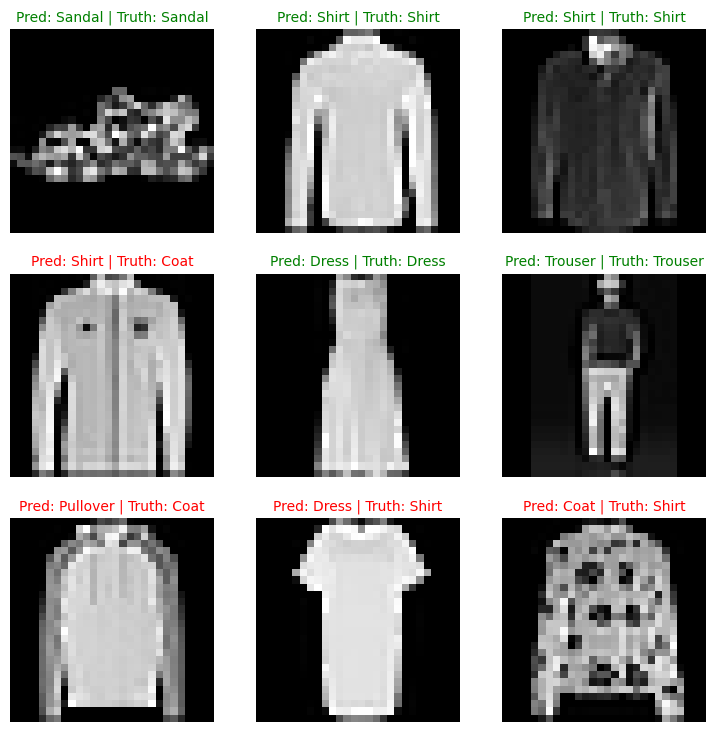

In [245]:
# Plot the predictions
plt.figure(figsize = (9, 9))
n_rows, n_cols = 3, 3
for i, sample in enumerate(test_samples):
  #create subplot to go through each case
  plt.subplot(n_rows, n_cols, i+1)
  #Plot the image
  plt.imshow(sample.squeeze(), cmap = 'gray')

  #Find the prediciton label as human readavle and not a tensor
  pred_label = class_names[pred_classes[i]]

  #Get the truth label
  truth_label = class_names[test_labels[i]]

  #Create the title
  title_text = f'Pred: {pred_label} | Truth: {truth_label}'

  #Check for equality
  if pred_label == truth_label:
    plt.title(title_text, fontsize = 10, color = 'green')
  else:
    plt.title(title_text, fontsize = 10, color = 'red')

  plt.axis(False)

## 10. Making a confusion matrix

Used for evaluating classification models visually

1. Make predictions with the trained model
2. make a confusion matrix 'torchmetrics.ConfusionMatrix'
3. Plot the confusion matrix

In [248]:
from tqdm.auto import tqdm

#1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc = 'Making predictions...'):
    #Send data and targets to target device
    X, y = X.to(device), y.to(device)
    #Do forward pass
    y_logits = model_2(X)
    #Turn predictions from logits --> prediction probabilities --> prediction labels
    y_pred = torch.softmax(y_logits.squeeze(), dim = 0).argmax(dim = 1)
    #Put predictions on CPU
    y_preds.append(y_pred.cpu())

#Concatenate list of predictions into a tensor
y_preds_tensor = torch.cat(y_preds)
y_preds_tensor[:10]

Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [249]:
len(y_preds_tensor)

10000

In [252]:
# See if rewuired packages are installed
try:
  import torchmetrics, mlxtend
  print(mlxtend.__version__)
  print(torchmetrics.__version__)
  assert mlxtend.__version__ == '0.19.0'
  assert torchmetrics.__version__ == '0.9.2'
except:
  !pip install -q torchmetrics -U mlxtend
  import torchmetrics, mlxtend
  from mlxtend.plotting import plot_confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.5/963.5 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 127.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.9 MB/s eta 0:00:00


In [253]:
import mlxtend
print(mlxtend.__version__)

0.23.4


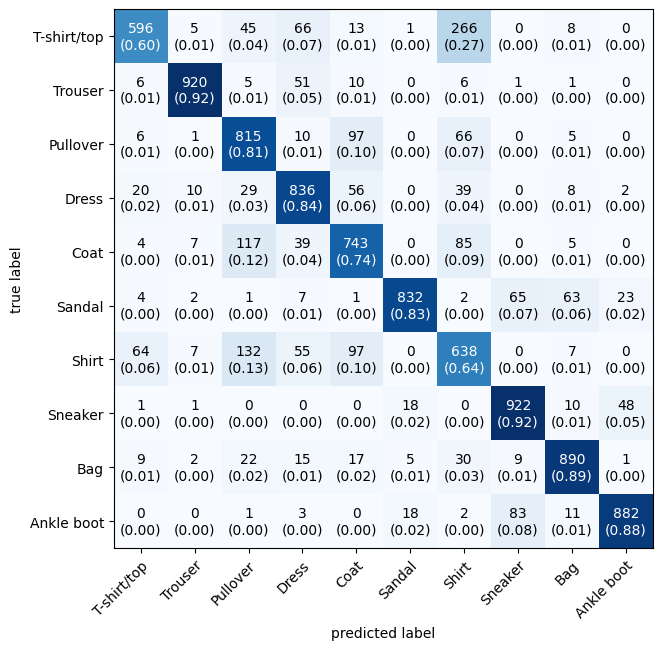

In [257]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2.setup confusion instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes = len(class_names),
                          task = 'multiclass')
confmat_tensor = confmat(preds = y_preds_tensor,
                         target = test_data.targets)
# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(conf_mat = confmat_tensor.numpy(),
                                show_normed = True,
                                figsize = (10, 7),
                                class_names = class_names,
                                cmap = plt.cm.Blues)

##11. Save and load best performing model

In [259]:
from pathlib import Path

#create a model directory path
model_path_cnn = Path('models')
model_path_cnn.mkdir(parents = True, exist_ok = True)

#Model save path
MODEL_NAME='03_Pytorch Computervision model 2.pth'
MODEL_SAVE_PATH = model_path_cnn / MODEL_NAME

#Save the model
print(f'Saving model to: {MODEL_SAVE_PATH}')
torch.save(obj = model_2.state_dict(),
           f = MODEL_SAVE_PATH)

Saving model to: models/03_Pytorch Computervision model 2.pth


In [261]:
#Create a new instance of the model cause we only saved the state_dict()
torch.manual_seed(42)

loaded_model_2 = FashionMNISTModelV2(input_shape = 1,
                                     hidden_units = 10,
                                     output_shape = len(class_names))
#load the saved state_dict()
loaded_model_2.load_state_dict(torch.load(f = MODEL_SAVE_PATH))

#send the model to target device
loaded_model_2.to(device)

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [262]:
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3285456895828247,
 'model_acc': 88.51837060702876}

In [263]:
#Evaluste loaded model
torch.manual_seed(42)

loaded_model_2_results = eval_model(model = loaded_model_2,
                                    data_loader = test_dataloader,
                                    loss_fn = loss_fn,
                                    accuracy_fn = accuracy_fn)
loaded_model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3285456895828247,
 'model_acc': 88.51837060702876}